# COVID-19 Vaccination vs Mortality Analysis

This Notebook analyzes the relationship between COVID-19 full vaccination rates and cumulative mortality rates across countries.

In [1]:
# Install required dependencies (if not already installed)
%pip install pandas numpy matplotlib seaborn scipy openpyxl -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All dependencies imported successfully!")

All dependencies imported successfully!


## 1. Load Dataset

The notebook now locates `DataCleaning/compact_clean.csv` automatically from the project root.

In [3]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = next((path for path in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (path / "DataCleaning" / "compact_clean.csv").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find DataCleaning/compact_clean.csv from the current notebook location.")
DATA_PATH = PROJECT_ROOT / "DataCleaning" / "compact_clean.csv"
OUTPUT_PATH = PROJECT_ROOT / "Insights" / "Vaccination_mortality" / "vaccination_vs_mortality_regression.png"
df = pd.read_csv(DATA_PATH)

print("Data shape:", df.shape)
print("Column names:", df.columns.tolist())

Data shape: (570606, 27)
Column names: ['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'code', 'continent', 'population', 'population_density', 'median_age', 'life_expectancy', 'gdp_per_capita', 'extreme_poverty', 'diabetes_prevalence', 'hospital_beds_per_thousand']


## 2. Data Preprocessing

In [4]:
# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Use 'country' or 'location' flexibly
country_col = 'country' if 'country' in df.columns else 'location'

# Group by country - take maximum values for cumulative indicators
agg = df.groupby(country_col).agg({
    'people_fully_vaccinated_per_hundred': 'max',      # Highest full vaccination rate
    'people_vaccinated_per_hundred': 'max',
    'total_deaths_per_million': 'max',                 # Cumulative deaths per million
    'new_deaths_per_million': 'mean',                  # Average daily deaths per million
    'continent': 'first' if 'continent' in df.columns else 'first',
    'population': 'first'
}).reset_index()

# Filter valid data
agg = agg.dropna(subset=['people_fully_vaccinated_per_hundred', 'total_deaths_per_million'])
agg = agg[agg['people_fully_vaccinated_per_hundred'] > 5]   # At least 5% fully vaccinated

print(f"Number of countries used: {len(agg)}")
print(agg.head())

Number of countries used: 223
       country  people_fully_vaccinated_per_hundred  \
0  Afghanistan                            45.270844   
1       Africa                            32.159496   
2      Albania                            45.244260   
3      Algeria                            14.251447   
5      Andorra                            67.109460   

   people_vaccinated_per_hundred  total_deaths_per_million  \
0                      47.195450                 197.09776   
1                      38.716625                 182.54872   
2                      47.717087                1275.98740   
3                      17.239624                 151.30595   
5                      72.643684                1994.43070   

   new_deaths_per_million continent    population  
0                0.087794      Asia  4.057885e+07  
1                0.081424      None  1.445863e+09  
2                0.568369    Europe  2.827614e+06  
3                0.067397    Africa  4.547739e+07  
5     

## 3. Scatter Plot + Regression Analysis

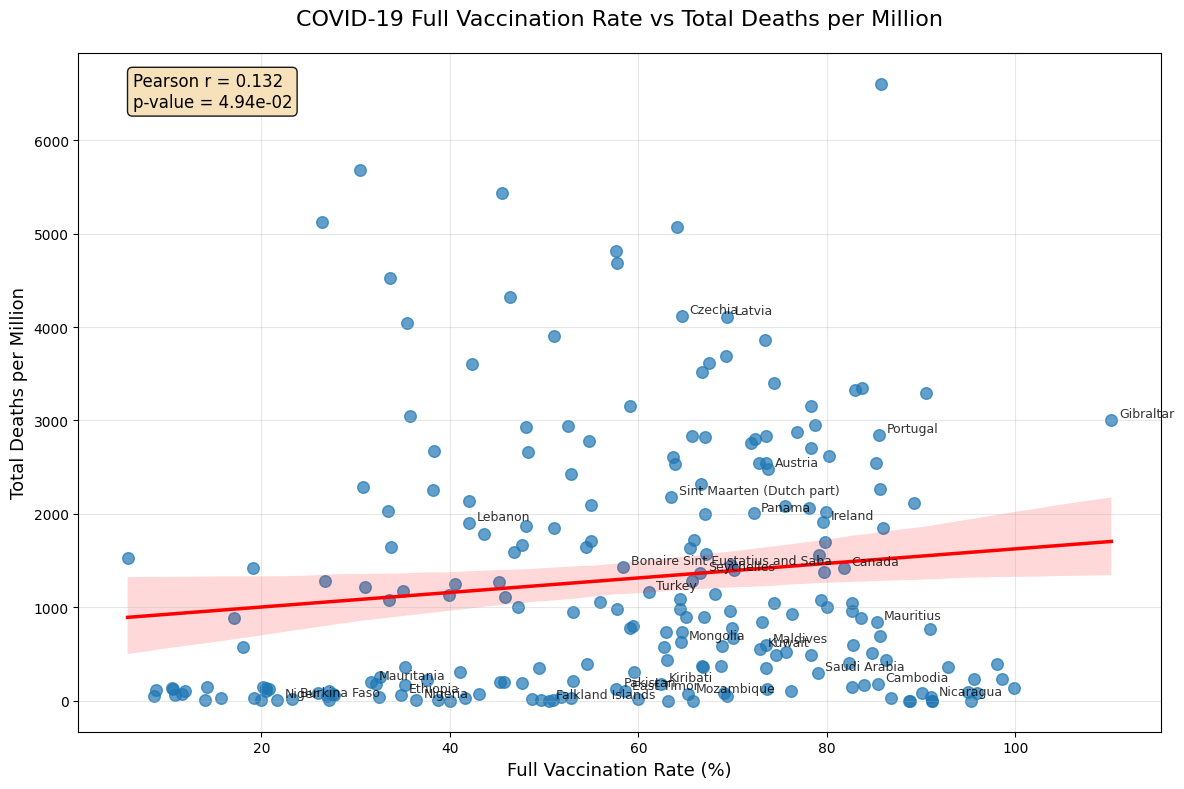

In [5]:
plt.figure(figsize=(12, 8))

sns.regplot(
    data=agg,
    x='people_fully_vaccinated_per_hundred',
    y='total_deaths_per_million',
    scatter_kws={'alpha': 0.7, 's': 70},
    line_kws={'color': 'red', 'linewidth': 2.5},
    ci=95
)

# Label some countries
for i, row in agg.sample(min(30, len(agg))).iterrows():
    plt.text(row['people_fully_vaccinated_per_hundred'] + 0.8, 
             row['total_deaths_per_million'] + 30, 
             row[country_col], fontsize=9, alpha=0.8)

plt.title('COVID-19 Full Vaccination Rate vs Total Deaths per Million', 
          fontsize=16, pad=20)
plt.xlabel('Full Vaccination Rate (%)', fontsize=13)
plt.ylabel('Total Deaths per Million', fontsize=13)
plt.grid(True, alpha=0.3)

# Show correlation
corr, p = stats.pearsonr(
    agg['people_fully_vaccinated_per_hundred'], 
    agg['total_deaths_per_million']
)
plt.annotate(f'Pearson r = {corr:.3f}\np-value = {p:.2e}', 
             xy=(0.05, 0.92), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.9))

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()